# Simulating different telescopes - API code

In [1]:
import copy
import os
import numpy as np
import scipy
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline


# lenstronomy module import
from lenstronomy.Util import image_util, data_util, util
import lenstronomy.Plots.plot_util as plot_util
from lenstronomy.SimulationAPI.sim_api import SimAPI
# lenstronomy imports
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.PointSource.point_source import PointSource
from lenstronomy.ImSim.image_model import ImageModel
import lenstronomy.Util.param_util as param_util
import lenstronomy.Util.simulation_util as sim_util
import lenstronomy.Util.image_util as image_util
from lenstronomy.Util import kernel_util
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF

import sncosmo
from astropy.table import Table
import warnings

In [2]:
#KWARGS G/R/I BAND

# Instrument setting from pre-defined configurations
from lenstronomy.SimulationAPI.ObservationConfig.LSST import LSST
LSST_g = LSST(band='g', psf_type='GAUSSIAN', coadd_years=10)
kwargs_g_band = LSST_g.kwargs_single_band()
LSST_r = LSST(band='r', psf_type='GAUSSIAN', coadd_years=10)
kwargs_r_band = LSST_r.kwargs_single_band()
LSST_i = LSST(band='i', psf_type='GAUSSIAN', coadd_years=10)
kwargs_i_band = LSST_i.kwargs_single_band()
# lenstronomy provides these setting to be imported with the SimulationAPI.observation_constructor routines.
#Tailored individual settings (as an example) in original API code

In [3]:
kwargs_model = {'lens_model_list': ['EPL', 'SHEAR'],  # list of lens models to be used
                'lens_light_model_list': ['SERSIC_ELLIPSE'],  # list of unlensed light models to be used
                'source_light_model_list': ['SERSIC_ELLIPSE'],  # list of extended source models to be used
                'point_source_model_list': ['SOURCE_POSITION']  # list of point source models to be used
    }

numpix = 64  # number of pixels per axis of the image to be modelled
# here we define the numerical options used in the ImSim module. 
# Have a look at the ImageNumerics class for detailed descriptions.
# If not further specified, the default settings are used.
kwargs_numerics = {'point_source_supersampling_factor': 1}
sim_g = SimAPI(numpix=numpix, kwargs_single_band=kwargs_g_band, kwargs_model=kwargs_model)
sim_r = SimAPI(numpix=numpix, kwargs_single_band=kwargs_r_band, kwargs_model=kwargs_model)
sim_i = SimAPI(numpix=numpix, kwargs_single_band=kwargs_i_band, kwargs_model=kwargs_model)


/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/lenstronomy/LensModel/lens_model.py:96: UserWarning: Astropy Cosmology is provided. Make sure your cosmology model is consistent with the cosmology_model argument.
  warnings.warn(


In [4]:
# KWARGS_LENS
# KWARGS SOURCE MAG 
# KWARGS LENS LIGHT MAG

#LENS KWARGS
gamma1, gamma2 = param_util.shear_polar2cartesian(phi=-0.5, gamma=0.06)
kwargs_lens = [{'theta_E': 1.66, 'gamma': 1.98, 
             'center_x': 0.0, 'center_y': 0.0, 
             'e1': 0.05, 'e2': 0.05},             
            {'gamma1': gamma1, 'gamma2': gamma2}  # SHEAR model
           ]


# g band
# lens light - FOREGROUND GALAXY
phi_G, q = 0.5, 0.8
e1, e2 = param_util.phi_q2_ellipticity(phi_G, q)
source_x = 0.
source_y = 0.3
kwargs_lens_light_mag_g = [{'magnitude': 15, 'R_sersic': 0.2, 'n_sersic': 1, 
                            'e1': e1, 'e2': e2, 
                            'center_x': 0.0, 'center_y': 0.0}]

# source light - SN HOST GALAXY
phi_G, q = 0.9, 0.9
e1, e2 = param_util.phi_q2_ellipticity(phi_G, q)
kwargs_source_mag_g = [{'magnitude': 19, 'R_sersic': 0.2, 'n_sersic': 1, 
                        'e1': e1, 'e2': e2, 
                        'center_x': source_x, 'center_y': source_y}]



# r-band
g_r_source = 1  # color mag_g - mag_r for source
g_r_lens = -1  # color mag_g - mag_r for lens light
g_r_ps = 0
kwargs_lens_light_mag_r = copy.deepcopy(kwargs_lens_light_mag_g)
kwargs_lens_light_mag_r[0]['magnitude'] -= g_r_lens

kwargs_source_mag_r = copy.deepcopy(kwargs_source_mag_g)
kwargs_source_mag_r[0]['magnitude'] -= g_r_source


# i-band
g_i_source = 2
g_i_lens = -2
g_i_ps = 0
kwargs_lens_light_mag_i = copy.deepcopy(kwargs_lens_light_mag_g)
kwargs_lens_light_mag_i[0]['magnitude'] -= g_i_lens

kwargs_source_mag_i = copy.deepcopy(kwargs_source_mag_g)
kwargs_source_mag_i[0]['magnitude'] -= g_i_source


In [5]:
#KWARGS_MODEL_TIME_VAR

z_lens = 0.5
z_source = 0.9
kwargs_model_time_var = {'lens_model_list': ['EPL', 'SHEAR'],  # list of lens models to be used
                'lens_light_model_list': ['SERSIC_ELLIPSE'],  # list of unlensed light models to be used
                'source_light_model_list': ['SERSIC_ELLIPSE'],  # list of extended source models to be used
                         'z_lens': z_lens, 'z_source': z_source
               }

In [6]:
# we define a time variable function in magnitude space
def var_func(time, band): #band either desg, desi, desr
    obs = Table({'time': [time],
             'band': [band],            #filters we are observing in 
             'gain': [1.],              #dw 
             'skynoise': [0],           #depends on exposure time, but will be addig noise later in lenstronomy, could set to 0
             'zp': [30.],               # zero point, what corresponds to 0 flux in this image - pixel values to magnitudes 
             'zpsys':['ab']})           # ab magnitudes, units of zero point

    model = sncosmo.Model(source='salt2')
    params = {'z': 0.0, 't0': 56200.0, 'x0':1.e-5, 'x1': 0.1, 'c': -0.1}  
    
    lcs = sncosmo.realize_lcs(obs, model, [params])
    flux = np.array(lcs[0]['flux'])
    # print(lcs[0]['time'])
    # print(flux)
    zero_points = np.array(obs['zp'])
    magnitude = zero_points - 2.5 * np.log10(flux)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        np.seterr(all='ignore')  # suppress divide, invalid, etc.
        magnitude = obs['zp'][0] - 2.5 * np.log10(np.where(flux > 0, flux, np.nan))
    return magnitude*0.5

var_func_g = lambda t: var_func(t, 'desg')
var_func_r = lambda t: var_func(t, 'desr')
var_func_i = lambda t: var_func(t, 'desi')

In [7]:
## GET IMAGES
from lenstronomy.SimulationAPI.point_source_variability import PointSourceVariability


ps_var_g = PointSourceVariability(source_x, source_y, var_func_g, numpix, kwargs_g_band, kwargs_model_time_var, kwargs_numerics,
                 kwargs_lens, kwargs_source_mag_g, kwargs_lens_light_mag_g, kwargs_ps_mag=None)

ps_var_r = PointSourceVariability(source_x, source_y, var_func_r, numpix, kwargs_r_band, kwargs_model_time_var, kwargs_numerics,
                 kwargs_lens, kwargs_source_mag_r, kwargs_lens_light_mag_r, kwargs_ps_mag=None)

ps_var_i = PointSourceVariability(source_x, source_y, var_func_i, numpix, kwargs_i_band, kwargs_model_time_var, kwargs_numerics,
                 kwargs_lens, kwargs_source_mag_i, kwargs_lens_light_mag_i, kwargs_ps_mag=None)

# these are the time delays of the multiple images (relative to the first appearing)
print(ps_var_g.delays)

t = 56050
flux_series = ps_var_g.point_source_time(t)
print(flux_series)


# fig, ax = plt.subplots(1, 3, sharex = True, figsize = (10, 10))
# times = [56050, 56200, 56400]
# for i, time in enumerate(times):
#     image_g = ps_var_g.image_time(time=time)
#     image_g += sim_g.noise_for_model(model=image_g)
    
#     image_r = ps_var_r.image_time(time=time)
#     image_r += sim_r.noise_for_model(model=image_r)
    
#     image_i = ps_var_i.image_time(time=time)
#     image_i += sim_i.noise_for_model(model=image_i)
    
    
    
#     img = np.zeros((image_g.shape[0], image_g.shape[1], 3), dtype=float)
#     img[:,:,0] = plot_util.sqrt(image_g, scale_min=0, scale_max=10000)
#     img[:,:,1] = plot_util.sqrt(image_r, scale_min=0, scale_max=10000)
#     img[:,:,2] = plot_util.sqrt(image_i, scale_min=0, scale_max=10000)
    
#     ax[i].clear()
#     ax[i].imshow(img, aspect='equal', origin='lower')
# plt.show()

[  0.         153.98521116]
[{'ra_image': array([-0.77957119, -0.44004686]), 'dec_image': array([ 1.85042408, -1.2206242 ]), 'point_amp': array([nan, nan])}]


/tmp/ipykernel_1298669/2139015843.py:18: RuntimeWarning: divide by zero encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)


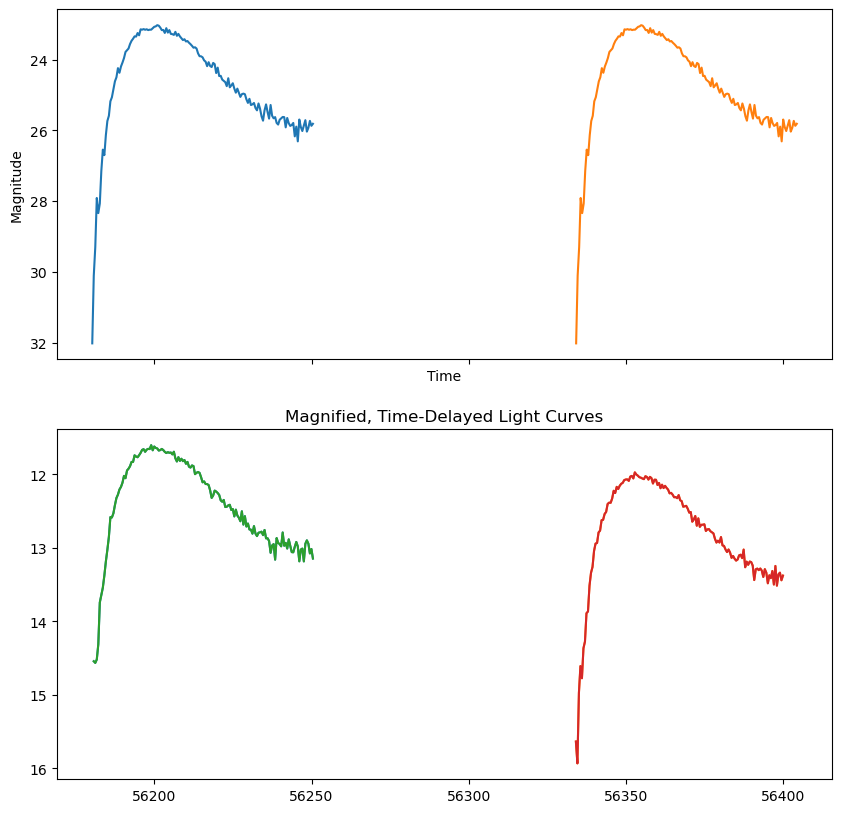

In [9]:
# also plot what the lightcurve would look like with the different time delays
# know intrinsic light curve and time delays
# plot the 0 time dely lightcurve, the ... delay light curve
# without the magnification

times = np.linspace(56160, 56400, 500)  # full light curve range
obs = Table({
    'time': times,
    'band': ['desg'] * len(times),
    'gain': [1.] * len(times),
    'skynoise': [0.] * len(times),
    'zp': [30.] * len(times),
    'zpsys': ['ab'] * len(times)
})

model = sncosmo.Model(source='salt2')
params = {'z': 0.01, 't0': 56200.0, 'x0':1.e-5, 'x1': 0.1, 'c': -0.1}
lcs = sncosmo.realize_lcs(obs, model, [params])
flux = np.array(lcs[0]['flux'])
zero_points = np.array(obs['zp'])
mags = zero_points - 2.5 * np.log10(flux)
times = np.array(obs['time'])

delays = ps_var_g.delays  

fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex = True)
for i, dt in enumerate(delays):
    axes[0].plot(times + dt, mags, label=f'delay = {dt:.1f} days')

plt.gca().invert_yaxis()
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Magnitude")
axes[0].invert_yaxis()




# Loop over time and extract point source amplitudes
fluxes = []
for i, t in enumerate(times):
    kwargs_ps = ps_var_g.point_source_time(t)
    fluxes.append(kwargs_ps[0]["point_amp"])

from amp2magnitude import amplitude2magnitude
mags = amplitude2magnitude(fluxes, 30)

for i in range(len(delays)):
    axes[1].plot(times, mags, label=f'Image {i+1}')
    
axes[1].set_title('Magnified, Time-Delayed Light Curves')
# axes[1].invert_yaxis()

plt.show()